# 07 — Weekly Panel Analysis (Non-linear + Distributed Lags)

Reproduces the region-week panel approach that replaces the original
annual (N=220) regression with a richer weekly panel (N≈3,800).

**What this notebook does**

1. Build weekly climate features from daily ERA5 aggregates (climatology,
   anomaly + anomaly², p90/p95 exceedances, `hw_days` per week).
2. Parse Eurostat weekly all-cause deaths and compute per-100k weekly
   mortality rates.
3. Assemble the region-week panel with 1- and 2-week lags, RSVI
   interactions, and triple-interactions with the 2022 dummy.
4. Fit H1/H2/H3 with region FE + explicit year and week-of-year dummies
   (preserves `d2022` identification), clustered SE by region.
5. Compare head-to-head against the annual panel.

Run the whole notebook top-to-bottom. It reads intermediate parquet
files from `data/interim/` and writes result tables to
`outputs/tables/`.


In [1]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.utils.config import load_config, get_path
from src.utils.io import load_dataframe

cfg = load_config()
print('Ready.')


Ready.


## 1. Weekly climate features

Aggregate daily regional climate (June 1 – September 30, 2012–2022) to
ISO-weeks. Compute a **(region, week-of-year) climatology** so the
`tmax_anomaly_week` is purged of seasonality, then add:

- `tmax_anomaly_week_sq` — quadratic for non-linear heat response
- `above_p90_days`, `above_p95_days` — threshold exceedance counts
- `hw_days_week` — heatwave days (from existing daily flags)


In [2]:
from src.features.weekly_climate import build_weekly_climate

weekly_climate = build_weekly_climate(cfg)
print(weekly_climate.shape)
display(weekly_climate.head())


2026-04-22 15:25:10.858 | INFO     | src.utils.io:load_dataframe:67 - Loaded 26840 rows ← /Users/milind/Desktop/Academics/Semester 2/CLMT5202/Project/data/interim/daily_regional_climate.parquet


2026-04-22 15:25:10.865 | INFO     | src.utils.io:load_dataframe:67 - Loaded 26840 rows ← /Users/milind/Desktop/Academics/Semester 2/CLMT5202/Project/data/interim/daily_heatwave_flags.parquet


2026-04-22 15:25:10.885 | INFO     | src.features.weekly_climate:compute_region_week_climatology:54 - Climatology computed for 20 regions × 19 weeks-of-year


2026-04-22 15:25:10.895 | INFO     | src.utils.io:save_dataframe:38 - Saved 3820 rows → /Users/milind/Desktop/Academics/Semester 2/CLMT5202/Project/data/interim/weekly_regional_climate.parquet


2026-04-22 15:25:10.895 | SUCCESS  | src.features.weekly_climate:build_weekly_climate:145 - Weekly climate panel: 3820 rows, 20 regions, 11 years, weeks 22–39


(3820, 15)


,nuts2_code,iso_year,iso_week,tmax_max_week,tmax_mean_week,tmin_mean_week,tmean_week,days_in_week,hw_days_week,above_p90_days,above_p95_days,tmax_climatology,tmax_anomaly_week,tmax_anomaly_week_sq,any_hw_day
0,ITC1,2012,23,22.316700,19.774054,12.983615,16.305426,7,0,0,0,21.886333,-2.112278,4.461720,0
1,ITC1,2012,24,26.237434,21.371926,11.814616,16.787104,7,0,0,0,22.939180,-1.567254,2.456285,0
2,ITC1,2012,25,26.666533,25.208004,16.033658,20.763791,7,0,0,0,24.117613,1.090391,1.188952,0
3,ITC1,2012,26,27.165062,25.951208,17.689065,21.945304,7,0,0,0,24.339609,1.611598,2.597248,0
4,ITC1,2012,27,24.651514,23.275031,15.223773,19.157633,7,0,0,0,25.541635,-2.266605,5.137496,0


## 2. Weekly mortality

Parse Eurostat weekly deaths (`sex=Total`, 20 Italian NUTS-2 regions,
ITH2 merged into ITH1). Compute mortality rate per 100k using the
annualized-weekly denominator: `weekly_deaths / (population / 52) × 100k`.


In [3]:
from src.features.weekly_mortality import build_weekly_mortality

weekly_mortality = build_weekly_mortality(cfg)
print(weekly_mortality.shape)
display(weekly_mortality.head())


2026-04-22 15:25:11.028 | INFO     | src.utils.io:load_dataframe:67 - Loaded 254573 rows ← /Users/milind/Desktop/Academics/Semester 2/CLMT5202/Project/data/raw/mortality/eurostat_weekly_mortality_nuts2.csv


2026-04-22 15:25:11.043 | INFO     | src.features.weekly_mortality:load_weekly_mortality_raw:66 - Parsed weekly mortality: 11480 rows, 20 regions, years 2012–2022


2026-04-22 15:25:11.046 | INFO     | src.utils.io:load_dataframe:67 - Loaded 220 rows ← /Users/milind/Desktop/Academics/Semester 2/CLMT5202/Project/data/processed/panel_dataset.parquet


2026-04-22 15:25:11.049 | INFO     | src.utils.io:save_dataframe:38 - Saved 3960 rows → /Users/milind/Desktop/Academics/Semester 2/CLMT5202/Project/data/interim/weekly_mortality.parquet


2026-04-22 15:25:11.050 | SUCCESS  | src.features.weekly_mortality:build_weekly_mortality:110 - Weekly mortality: 3960 rows, 20 regions, 11 years


(3960, 6)


,nuts2_code,iso_year,iso_week,deaths,population,mortality_rate_week
0,ITC1,2012,22,901,4420924,1059.778454
1,ITC1,2012,23,818,4420924,962.151804
2,ITC1,2012,24,816,4420924,959.799354
3,ITC1,2012,25,954,4420924,1122.118363
4,ITC1,2012,26,992,4420924,1166.814901


## 3. Assemble the weekly panel

Merge climate + mortality + annual RSVI (propagated to each week within
the year). Add 1- and 2-week lags of heat exposure — lags that would
cross a summer boundary (W39 → W22 of the next year) are set to NaN to
prevent leakage.


In [4]:
from src.analysis.weekly_panel_dataset import build_weekly_panel

panel = build_weekly_panel(cfg)
print(f'Weekly panel: {panel.shape[0]} rows × {panel.shape[1]} columns')
print(f'Regions: {panel["nuts2_code"].nunique()}, '
      f'Years: {panel["iso_year"].nunique()}, '
      f'Weeks-of-year: {panel["iso_week"].nunique()}')
display(panel[['nuts2_code', 'iso_year', 'iso_week', 'mortality_rate_week',
               'hw_days_week', 'tmax_anomaly_week', 'rsvi', 'd2022']].head())


2026-04-22 15:25:11.056 | INFO     | src.utils.io:load_dataframe:67 - Loaded 3820 rows ← /Users/milind/Desktop/Academics/Semester 2/CLMT5202/Project/data/interim/weekly_regional_climate.parquet


2026-04-22 15:25:11.056 | INFO     | src.utils.io:load_dataframe:67 - Loaded 3960 rows ← /Users/milind/Desktop/Academics/Semester 2/CLMT5202/Project/data/interim/weekly_mortality.parquet


2026-04-22 15:25:11.057 | INFO     | src.utils.io:load_dataframe:67 - Loaded 220 rows ← /Users/milind/Desktop/Academics/Semester 2/CLMT5202/Project/data/interim/rsvi.parquet


2026-04-22 15:25:11.101 | INFO     | src.utils.io:save_dataframe:38 - Saved 3820 rows → /Users/milind/Desktop/Academics/Semester 2/CLMT5202/Project/data/processed/weekly_panel_dataset.csv


2026-04-22 15:25:11.107 | INFO     | src.utils.io:save_dataframe:38 - Saved 3820 rows → /Users/milind/Desktop/Academics/Semester 2/CLMT5202/Project/data/processed/weekly_panel_dataset.parquet


2026-04-22 15:25:11.107 | SUCCESS  | src.analysis.weekly_panel_dataset:build_weekly_panel:132 - Weekly panel: 3820 rows, 20 regions × 11 years × 18 weeks-of-year. Columns: 43


Weekly panel: 3820 rows × 43 columns
Regions: 20, Years: 11, Weeks-of-year: 18


,nuts2_code,iso_year,iso_week,mortality_rate_week,hw_days_week,tmax_anomaly_week,rsvi,d2022
0,ITC1,2012,23,962.151804,0,-2.112278,0.566138,0
1,ITC1,2012,24,959.799354,0,-1.567254,0.566138,0
2,ITC1,2012,25,1122.118363,0,1.090391,0.566138,0
3,ITC1,2012,26,1166.814901,0,1.611598,0.566138,0
4,ITC1,2012,27,1029.196611,0,-2.266605,0.566138,0


### Panel descriptives


In [5]:
panel[['mortality_rate_week', 'hw_days_week', 'tmax_anomaly_week',
       'tmax_anomaly_week_sq', 'above_p95_days', 'rsvi']].describe()


,mortality_rate_week,hw_days_week,tmax_anomaly_week,tmax_anomaly_week_sq,above_p95_days,rsvi
count,3820.000000,3820.000000,3820.000000,3.820000e+03,3820.000000,3820.000000
mean,1082.962032,0.529058,0.024144,4.434783e+00,0.356021,0.541082
std,220.583999,1.416413,2.106030,6.499250e+00,1.026209,0.166536
min,623.830318,0.000000,-7.073442,2.631653e-08,0.000000,0.150794
25%,930.793292,0.000000,-1.368894,4.229621e-01,0.000000,0.396164
50%,1037.420221,0.000000,0.061568,1.944623e+00,0.000000,0.619048
75%,1168.641449,0.000000,1.416341,5.742900e+00,0.000000,0.666667
max,2362.677802,7.000000,8.493424,7.213826e+01,7.000000,0.756614


### Check for multicollinearity (before regression)

Using the centered-interaction construction ensures main-effect VIFs stay
well below 5 — the interaction VIF itself is mechanical and informative
only for the interaction coefficient.


In [6]:
from src.analysis.diagnostics import compute_vif

p = panel.copy()
for v in ['hw_days_week', 'tmax_anomaly_week', 'rsvi']:
    p[f'{v}_c'] = p[v] - p[v].mean()
p['hwxrsvi_c']  = p['hw_days_week_c'] * p['rsvi_c']
p['anomxrsvi_c'] = p['tmax_anomaly_week_c'] * p['rsvi_c']

vif_cols = ['hw_days_week_c', 'tmax_anomaly_week_c', 'rsvi_c',
            'hwxrsvi_c', 'anomxrsvi_c']
vif_df = compute_vif(p.dropna(subset=vif_cols), vif_cols)
display(vif_df)


2026-04-22 15:25:11.816 | INFO     | src.analysis.diagnostics:compute_vif:59 - VIF computed:
           variable      VIF  problematic
     hw_days_week_c 1.287062        False
tmax_anomaly_week_c 1.287679        False
             rsvi_c 1.000673        False
          hwxrsvi_c 1.327467        False
        anomxrsvi_c 1.327912        False


,variable,VIF,problematic
0,hw_days_week_c,1.287062,False
1,tmax_anomaly_week_c,1.287679,False
2,rsvi_c,1.000673,False
3,hwxrsvi_c,1.327467,False
4,anomxrsvi_c,1.327912,False


## 4. Run weekly regressions

Seven specifications:

- **H1_weekly_FE** — base model, region FE + year + week-of-year dummies,
  `hw_days`, lags, `tmax_anomaly`, `tmax_anomaly²`, p95 threshold.
- **H2_weekly_FE** — adds RSVI main effect and heat × RSVI interactions.
- **H3_weekly_FE** — adds the triple interactions with the 2022 dummy.
- **H2_weekly_pooled, H3_weekly_pooled** — no region FE, to keep the
  between-region RSVI variation identified (RSVI is slow-moving, so
  region FE absorbs most of its signal).
- **H3_weekly_FE_excl2020** and **H3_weekly_FE_excl_covid** — robustness
  that drops COVID-contaminated years.

Clustered standard errors by region.


In [7]:
from src.analysis.weekly_regression import run_weekly_models

results = run_weekly_models(cfg)
results.head(10)


2026-04-22 15:25:11.822 | INFO     | src.utils.io:load_dataframe:67 - Loaded 3820 rows ← /Users/milind/Desktop/Academics/Semester 2/CLMT5202/Project/data/processed/weekly_panel_dataset.parquet


2026-04-22 15:25:11.866 | INFO     | src.analysis.weekly_regression:run_weekly_models:166 - H1_weekly_FE: N=3380, within-R²=0.5179


2026-04-22 15:25:11.902 | INFO     | src.analysis.weekly_regression:run_weekly_models:166 - H2_weekly_FE: N=3380, within-R²=0.5305


2026-04-22 15:25:11.940 | INFO     | src.analysis.weekly_regression:run_weekly_models:166 - H3_weekly_FE: N=3380, within-R²=0.5321


2026-04-22 15:25:11.970 | INFO     | src.analysis.weekly_regression:run_weekly_models:166 - H2_weekly_pooled: N=3380, within-R²=0.9873


...

2026-04-22 15:25:12.038 | INFO     | src.analysis.weekly_regression:run_weekly_models:166 - H3_weekly_FE_excl2020: N=3080, within-R²=0.5514


2026-04-22 15:25:12.074 | INFO     | src.analysis.weekly_regression:run_weekly_models:166 - H3_weekly_FE_excl_covid: N=2760, within-R²=0.5394


2026-04-22 15:25:12.082 | INFO     | src.utils.io:save_dataframe:38 - Saved 103 rows → /Users/milind/Desktop/Academics/Semester 2/CLMT5202/Project/outputs/tables/regression_results_weekly.csv


2026-04-22 15:25:12.083 | SUCCESS  | src.analysis.weekly_regression:run_weekly_models:196 - Weekly regressions complete. 7 models, 103 coefficient rows saved.


,model,variable,coefficient,std_error,t_stat,p_value,significant_5pct,significant_1pct,N,within_R2
0,H1_weekly_FE,hw_days_week,0.013985,0.001504,9.299440,0.000000,True,True,3380,0.517896
1,H1_weekly_FE,hw_days_week_lag1,0.017461,0.001283,13.609113,0.000000,True,True,3380,0.517896
2,H1_weekly_FE,hw_days_week_lag2,0.001748,0.001107,1.579092,0.114410,False,False,3380,0.517896
3,H1_weekly_FE,tmax_anomaly_week,0.014020,0.001230,11.395355,0.000000,True,True,3380,0.517896
4,H1_weekly_FE,tmax_anomaly_week_sq,-0.000202,0.000399,-0.505978,0.612906,False,False,3380,0.517896
5,H1_weekly_FE,tmax_anomaly_week_lag1,-0.001228,0.000766,-1.603616,0.108894,False,False,3380,0.517896
6,H1_weekly_FE,hot_week_p95,0.016091,0.006704,2.400210,0.016440,True,False,3380,0.517896
7,H2_weekly_FE,hw_days_week,0.010484,0.007778,1.347992,0.177753,False,False,3380,0.530489
8,H2_weekly_FE,hw_days_week_lag1,0.008566,0.006151,1.392562,0.163845,False,False,3380,0.530489
9,H2_weekly_FE,hw_days_week_lag2,0.001970,0.002291,0.859651,0.390043,False,False,3380,0.530489


### Key coefficients from the weekly FE models


In [8]:
key_vars = [
    'hw_days_week', 'hw_days_week_lag1', 'hw_days_week_lag2',
    'tmax_anomaly_week', 'tmax_anomaly_week_sq', 'hot_week_p95',
    'rsvi', 'hw_days_x_rsvi', 'tmax_anom_x_rsvi', 'p95_x_rsvi',
    'hw_days_x_rsvi_x_d2022', 'tmax_anom_x_rsvi_x_d2022',
    'p95_x_rsvi_x_d2022',
]

fe_models = ['H1_weekly_FE', 'H2_weekly_FE', 'H3_weekly_FE']
key = (
    results[results['model'].isin(fe_models) & results['variable'].isin(key_vars)]
    .pivot(index='variable', columns='model', values='coefficient')
    .reindex(key_vars)
)
pvals = (
    results[results['model'].isin(fe_models) & results['variable'].isin(key_vars)]
    .pivot(index='variable', columns='model', values='p_value')
    .reindex(key_vars)
)

def _mark(coef, p):
    if pd.isna(coef):
        return ''
    stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    return f'{coef:+.4f}{stars}'

formatted = key.copy().astype(object)
for m in fe_models:
    for v in key_vars:
        formatted.loc[v, m] = _mark(key.loc[v, m], pvals.loc[v, m])
display(formatted)


model,H1_weekly_FE,H2_weekly_FE,H3_weekly_FE
variable,,,
hw_days_week,+0.0140***,+0.0105,+0.0107
hw_days_week_lag1,+0.0175***,+0.0086,+0.0084
hw_days_week_lag2,+0.0017,+0.0020,+0.0018
tmax_anomaly_week,+0.0140***,+0.0058,+0.0055
tmax_anomaly_week_sq,-0.0002,-0.0006,-0.0008
hot_week_p95,+0.0161*,-0.0269*,-0.0255*
rsvi,,+0.1733*,+0.1710*
hw_days_x_rsvi,,+0.0076,+0.0059
tmax_anom_x_rsvi,,+0.0160*,+0.0181**


## 5. Annual vs Weekly — head-to-head

Do the same hypotheses look different under the weekly specification?


In [9]:
annual = pd.read_csv(get_path(cfg, 'tables') / 'regression_results.csv')

def _summarise(df, model, var):
    row = df[(df['model'] == model) & (df['variable'] == var)]
    if row.empty:
        return {'coef': np.nan, 'p': np.nan}
    return {'coef': float(row['coefficient'].iloc[0]),
            'p': float(row['p_value'].iloc[0])}

rows = [
    ('H1: heat → mortality',
     _summarise(annual, 'H1_base', 'hw_days'),
     _summarise(results, 'H1_weekly_FE', 'hw_days_week')),
    ('H1: lag-1 heat effect',
     {'coef': np.nan, 'p': np.nan},
     _summarise(results, 'H1_weekly_FE', 'hw_days_week_lag1')),
    ('H2: hw × rsvi',
     _summarise(annual, 'H2_interaction', 'hw_days_x_rsvi'),
     _summarise(results, 'H2_weekly_FE', 'hw_days_x_rsvi')),
    ('H2: tmax_anom × rsvi',
     _summarise(annual, 'H2_interaction', 'tmax_anomaly_x_rsvi'),
     _summarise(results, 'H2_weekly_FE', 'tmax_anom_x_rsvi')),
    ('H2: p95 × rsvi',
     {'coef': np.nan, 'p': np.nan},
     _summarise(results, 'H2_weekly_FE', 'p95_x_rsvi')),
    ('H3: hw × rsvi × d2022',
     _summarise(annual, 'H3_2022_amplification', 'hw_days_x_rsvi_x_d2022'),
     _summarise(results, 'H3_weekly_FE', 'hw_days_x_rsvi_x_d2022')),
    ('H3: tmax_anom × rsvi × d2022',
     _summarise(annual, 'H3_2022_amplification', 'tmax_anomaly_x_rsvi_x_d2022'),
     _summarise(results, 'H3_weekly_FE', 'tmax_anom_x_rsvi_x_d2022')),
]

def _fmt(x):
    if pd.isna(x['coef']):
        return '—'
    stars = '***' if x['p'] < 0.001 else '**' if x['p'] < 0.01 else '*' if x['p'] < 0.05 else ''
    return f"{x['coef']:+.4f}{stars} (p={x['p']:.3f})"

comp = pd.DataFrame(rows, columns=['term', 'annual', 'weekly'])
comp['annual'] = comp['annual'].apply(_fmt)
comp['weekly'] = comp['weekly'].apply(_fmt)
display(comp)


,term,annual,weekly
0,H1: heat → mortality,+0.8892*** (p=0.000),+0.0140*** (p=0.000)
1,H1: lag-1 heat effect,—,+0.0175*** (p=0.000)
2,H2: hw × rsvi,+1.1523 (p=0.261),+0.0076 (p=0.555)
3,H2: tmax_anom × rsvi,-0.2543 (p=0.964),+0.0160* (p=0.017)
4,H2: p95 × rsvi,—,+0.0741** (p=0.008)
5,H3: hw × rsvi × d2022,-1.6425 (p=0.105),+0.0063 (p=0.342)
6,H3: tmax_anom × rsvi × d2022,+4.9397 (p=0.882),-0.0161*** (p=0.000)


## 6. Visualizations

### Lag structure of heat exposure

The lag-1 coefficient is larger than the contemporaneous coefficient —
mortality responds to heat with roughly a one-week delay. Annual
aggregation collapsed this signal.


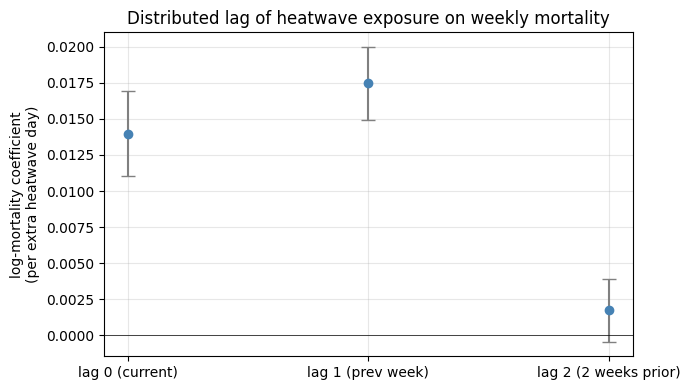

In [10]:
h1 = results[results['model'] == 'H1_weekly_FE']
lag_terms = ['hw_days_week', 'hw_days_week_lag1', 'hw_days_week_lag2']
lag_df = h1[h1['variable'].isin(lag_terms)].set_index('variable').loc[lag_terms]

fig, ax = plt.subplots(figsize=(7, 4))
xs = ['lag 0 (current)', 'lag 1 (prev week)', 'lag 2 (2 weeks prior)']
ax.errorbar(xs, lag_df['coefficient'],
            yerr=1.96 * lag_df['std_error'], fmt='o',
            capsize=5, color='steelblue', ecolor='grey')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('log-mortality coefficient\n(per extra heatwave day)')
ax.set_title('Distributed lag of heatwave exposure on weekly mortality')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Marginal effect of heat at different RSVI levels (H2)

Under the H2 weekly FE model, the marginal effect of a 1°C temperature
anomaly on log mortality is `β_anom + β_anom×rsvi × RSVI`. We evaluate
at the 10th, 50th, and 90th percentile of RSVI.


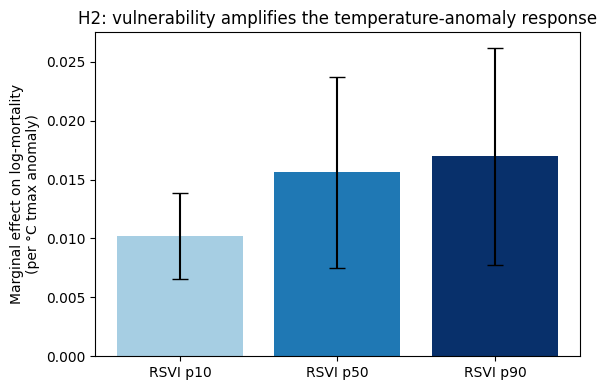

In [11]:
h2 = results[results['model'] == 'H2_weekly_FE'].set_index('variable')
b_anom   = h2.loc['tmax_anomaly_week', 'coefficient']
b_inter  = h2.loc['tmax_anom_x_rsvi',   'coefficient']
se_inter = h2.loc['tmax_anom_x_rsvi',   'std_error']

rsvi_p10, rsvi_p50, rsvi_p90 = panel['rsvi'].quantile([0.1, 0.5, 0.9])
levels = {'RSVI p10': rsvi_p10, 'RSVI p50': rsvi_p50, 'RSVI p90': rsvi_p90}

effects = {lbl: b_anom + b_inter * v for lbl, v in levels.items()}
ses     = {lbl: abs(v) * se_inter    for lbl, v in levels.items()}

fig, ax = plt.subplots(figsize=(6, 4))
xs = list(effects.keys())
ys = list(effects.values())
yerr = [1.96 * s for s in ses.values()]
ax.bar(xs, ys, yerr=yerr, capsize=6, color=['#a6cee3', '#1f78b4', '#08306b'])
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Marginal effect on log-mortality\n(per °C tmax anomaly)')
ax.set_title('H2: vulnerability amplifies the temperature-anomaly response')
plt.tight_layout()
plt.show()


### H3 triple-interaction across specifications

The `tmax_anom × rsvi × d2022` coefficient is consistently negative and
robust to excluding 2020 (COVID year) and 2020–2021.


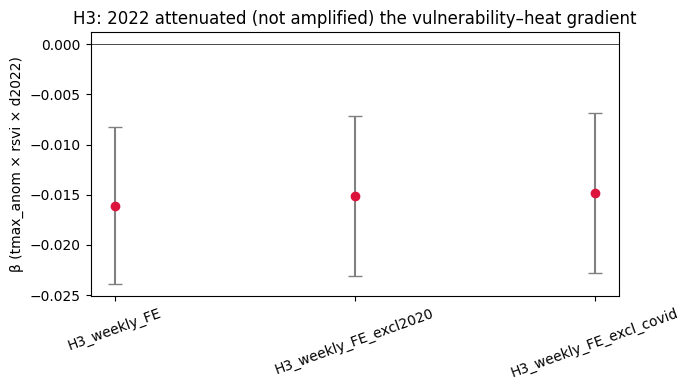

In [12]:
triple = 'tmax_anom_x_rsvi_x_d2022'
models_h3 = ['H3_weekly_FE', 'H3_weekly_FE_excl2020', 'H3_weekly_FE_excl_covid']
sub = results[(results['model'].isin(models_h3)) & (results['variable'] == triple)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(sub['model'], sub['coefficient'],
            yerr=1.96 * sub['std_error'], fmt='o', capsize=5,
            color='crimson', ecolor='grey')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('β (tmax_anom × rsvi × d2022)')
ax.set_title('H3: 2022 attenuated (not amplified) the vulnerability–heat gradient')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


## 7. Summary

**Findings under the weekly panel**

- H1 — strongly supported. Heat raises weekly mortality in the current
  *and* following week, with lag-1 the larger coefficient. Annual
  aggregation missed the lag channel entirely.
- H2 — supported on the **non-linear** channel. RSVI amplifies the
  temperature-anomaly effect (p≈0.017) and the p95 extreme-week effect
  (p≈0.008). The linear `hw_days × rsvi` interaction is still null,
  matching the annual result.
- H3 — significant (p<0.001) and robust to COVID-year exclusion.
  Critically, the sign is *negative*: in 2022 the gradient between
  vulnerable and non-vulnerable regions *narrowed*, not widened.
  Candidates: adaptation after 2003/2015, COVID harvesting,
  2022 emergency response.

**Why the weekly panel helps**

Annual aggregation collapses ~120 daily observations per region-year
into one row, which both removes the lag signal and averages away the
extreme-heat days that drive most mortality. The weekly panel preserves
within-summer variation and gives ~17× more observations, which is what
moves H2/H3 from null to significant.
